# Luật số lớn và Định lý giới hạn trung tâm

Notebook này mô phỏng và chứng minh thực nghiệm Luật số lớn (LLN) và Định lý giới hạn trung tâm (CLT) trên tập dữ liệu Wine Quality.

## Import & Setup

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import sys
import os
from IPython.display import Markdown, display

# Thêm đường dẫn source vào hệ thống
sys.path.append(os.path.abspath(".."))
from source.utils import (
    mean, variance, standard_deviation, covariance, correlation,
    mle_normal_univariate, mle_normal_multivariate,
    log_likelihood_normal, log_likelihood_univariate,
    simulate_lln, simulate_clt
)
from source.visualization import (
    distribution, dot_diagram, box_plot,
    plot_lln_convergence_grid, plot_clt_convergence_grid
)

%reload_ext autoreload
%autoreload 2

In [36]:
# Tải dataset
df = pd.read_csv('../data/winequality-red.csv', sep=';')
features = df.drop(columns=['quality'])
var_list = features.columns.tolist()
n_total, p_dim = features.shape

display(Markdown(f"**Số lượng mẫu (samples):** $n = {df.shape[0]}$"))
display(Markdown(f"**Số lượng biến (features):** $p = {features.shape[1]}$"))
display(Markdown(f"**Danh sách các biến:** {', '.join(features.columns.tolist())}"))

**Số lượng mẫu (samples):** $n = 1599$

**Số lượng biến (features):** $p = 11$

**Danh sách các biến:** fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol

## 1. Chuẩn bị dữ liệu

Giai đoạn này chuẩn bị sẵn một số giá trị cần thiết để cần cho bước sau. Chưa đi sâu vào phân tích/mô phỏng.

In [37]:
# Thống kê mô tả
display(Markdown("### Thống kê mô tả (đã phân tích ở notebook 1):"))
display(df.describe().round(4))

### Thống kê mô tả (đã phân tích ở notebook 1):

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000,1599.0000
mean,8.3196,0.5278,0.2710,2.5388,0.0875,15.8749,46.4678,0.9967,3.3111,0.6581,10.4230,5.6360
std,1.7411,0.1791,0.1948,1.4099,0.0471,10.4602,32.8953,0.0019,0.1544,0.1695,1.0657,0.8076
min,4.6000,0.1200,0.0000,0.9000,0.0120,1.0000,6.0000,0.9901,2.7400,0.3300,8.4000,3.0000
25%,7.1000,0.3900,0.0900,1.9000,0.0700,7.0000,22.0000,0.9956,3.2100,0.5500,9.5000,5.0000
50%,7.9000,0.5200,0.2600,2.2000,0.0790,14.0000,38.0000,0.9968,3.3100,0.6200,10.2000,6.0000
75%,9.2000,0.6400,0.4200,2.6000,0.0900,21.0000,62.0000,0.9978,3.4000,0.7300,11.1000,6.0000
max,15.9000,1.5800,1.0000,15.5000,0.6110,72.0000,289.0000,1.0037,4.0100,2.0000,14.9000,8.0000


In [38]:
# Tính mu và sigma quần thể cho tất cả các biến
pop_params = pd.DataFrame({
    'Variable': features.columns,
    'Population Mean (μ)': [mean(features[col]) for col in features.columns],
    'Population Std Dev (σ)': [standard_deviation(features[col], is_population=True) for col in features.columns]
})

pop_means = dict(zip(pop_params['Variable'], pop_params['Population Mean (μ)']))
pop_stds = dict(zip(pop_params['Variable'], pop_params['Population Std Dev (σ)']))

display(Markdown("### Tham số quần thể:"))
display(pop_params)

### Tham số quần thể:

,Variable,Population Mean (μ),Population Std Dev (σ)
0,fixed acidity,8.319637,1.740552
1,volatile acidity,0.527821,0.179004
2,citric acid,0.270976,0.194740
3,residual sugar,2.538806,1.409487
4,chlorides,0.087467,0.047051
5,free sulfur dioxide,15.874922,10.456886
6,total sulfur dioxide,46.467792,32.885037
7,density,0.996747,0.001887
8,pH,3.311113,0.154338
9,sulphates,0.658149,0.169454


---
## 2. Ước lượng Triển vọng Cực đại (MLE)

### 2.1 Tóm tắt lý thuyết

**Bài toán:** Cho $X_1, X_2, \ldots, X_n$ là các mẫu i.i.d. từ phân phối chuẩn đa biến $N_p(\mu, \Sigma)$. Tìm $\mu$ và $\Sigma$ sao cho **khả năng sinh ra dữ liệu quan sát được là cao nhất**.

**Hàm mật độ xác suất:**
$$f(x) = \frac{1}{(2\pi)^{p/2}|\Sigma|^{1/2}} \exp\!\left(-\frac{1}{2}(x-\mu)^\top\Sigma^{-1}(x-\mu)\right)$$

**Hàm likelihood** (xác suất đồng thời của toàn bộ mẫu):
$$L(\mu, \Sigma) = \prod_{j=1}^{n} f(x_j)$$

**Log-likelihood** (lấy log để đơn giản hóa tính toán):
$$\ell(\mu, \Sigma) = -\frac{np}{2}\ln(2\pi) - \frac{n}{2}\ln|\Sigma| - \frac{1}{2}\sum_{j=1}^{n}(x_j-\mu)^\top\Sigma^{-1}(x_j-\mu)$$

**Tìm nghiệm bằng cách đặt đạo hàm bằng 0:**

$$\frac{\partial\,\ell}{\partial\,\mu} = 0 \quad\Rightarrow\quad \boxed{\hat{\mu}_{MLE} = \bar{x} = \frac{1}{n}\sum_{j=1}^{n} x_j}$$

$$\frac{\partial\,\ell}{\partial\,\Sigma^{-1}} = 0 \quad\Rightarrow\quad \boxed{\hat{\Sigma}_{MLE} = \frac{1}{n}\sum_{j=1}^{n}(x_j - \bar{x})(x_j - \bar{x})^\top}$$

> **Kết luận lý thuyết:**
> - $\hat{\mu}_{MLE}$ chính xác là **trung bình mẫu** $\bar{x}$.
> - $\hat{\Sigma}_{MLE}$ là ma trận hiệp phương sai **chia $n$** (tổng thể), khác với ước lượng không chệch $S$ chia $n-1$ (mẫu).
> - $\hat{\Sigma}_{MLE}$ là ước lượng **chệch** (biased) của $\Sigma$ thực, nhưng khi $n$ lớn thì sự khác biệt rất nhỏ: $S = \dfrac{n}{n-1}\hat{\Sigma}_{MLE}$.

---

### 2.2 Ý tưởng kiểm chứng thực nghiệm

Ta kiểm chứng MLE theo ba hướng:

**Hướng 1 — So sánh log-likelihood đa biến:**  
Nếu $\hat{\Sigma}_{MLE}$ (chia $n$) thực sự là nghiệm tối ưu, thì log-likelihood tại $\hat{\Sigma}_{MLE}$ phải **cao hơn** tại $S_{unbiased}$ (chia $n-1$).

**Hướng 2 — Trực quan hóa log-likelihood theo $\mu$:**  
Với từng biến đơn lẻ, vẽ đường log-likelihood khi $\mu$ thay đổi, cố định $\sigma^2$ tại MLE. Đỉnh phải rơi đúng tại $\bar{x}$.

**Hướng 3 — Trực quan hóa log-likelihood theo $\sigma^2$:**  
Cố định $\mu = \bar{x}$, thay đổi $\sigma^2$. Đỉnh phải rơi đúng tại $\hat{\sigma}^2_{MLE}$ (chia $n$), không phải tại $S^2$ (chia $n-1$).

In [39]:
mle_results = {}
for col in var_list:
    mle_results[col] = mle_normal_univariate(features[col])

mle_table = pd.DataFrame({
    'μ̂_MLE  (= x̄)':         [round(mle_results[c]['mu_hat'],     4) for c in var_list],
    'σ̂²_MLE (chia n)':       [round(mle_results[c]['sigma2_hat'], 6) for c in var_list],
    'S²_unbiased (chia n-1)': [round(variance(features[c]),        6) for c in var_list],
    'σ̂_MLE':                 [round(mle_results[c]['sigma_hat'],  4) for c in var_list],
}, index=var_list)

display(Markdown("### Ước lượng MLE cho từng biến:"))
display(Markdown(
    f"$n = {n_total}$, nên $n/(n-1) = {n_total/(n_total-1):.6f}$ "
    f"→ $\\hat{{\\Sigma}}_{{MLE}}$ và $S_{{unbiased}}$ chênh nhau rất nhỏ."
))
display(mle_table)

### Ước lượng MLE cho từng biến:

$n = 1599$, nên $n/(n-1) = 1.000626$ → $\hat{\Sigma}_{MLE}$ và $S_{unbiased}$ chênh nhau rất nhỏ.

,μ̂_MLE (= x̄),σ̂²_MLE (chia n),S²_unbiased (chia n-1),σ̂_MLE
fixed acidity,8.3196,3.029521,3.031416,1.7406
volatile acidity,0.5278,0.032042,0.032062,0.1790
citric acid,0.2710,0.037924,0.037947,0.1947
residual sugar,2.5388,1.986654,1.987897,1.4095
chlorides,0.0875,0.002214,0.002215,0.0471
free sulfur dioxide,15.8749,109.346457,109.414884,10.4569
total sulfur dioxide,46.4678,1081.425636,1082.102373,32.8850
density,0.9967,0.000004,0.000004,0.0019
pH,3.3111,0.023820,0.023835,0.1543
sulphates,0.6581,0.028715,0.028733,0.1695


### 2.4 Kiểm chứng — So sánh log-likelihood đa biến

In [40]:
X = features.values.astype(float)
mle_mv = mle_normal_multivariate(X)

mu_hat         = mle_mv['mu_hat']
Sigma_mle      = mle_mv['Sigma_hat']
Sigma_unbiased = mle_mv['Sigma_unbiased']

ll_mle      = log_likelihood_normal(X, mu_hat, Sigma_mle)
ll_unbiased = log_likelihood_normal(X, mu_hat, Sigma_unbiased)

display(Markdown("### Kiểm chứng: $\\hat{\\Sigma}_{MLE}$ cho log-likelihood cao nhất"))
print(f"  Log-likelihood tại Σ̂_MLE (chia n)   : {ll_mle:.4f}")
print(f"  Log-likelihood tại S_unbiased (chia n-1) : {ll_unbiased:.4f}")
print(f"  Σ̂_MLE cho log-likelihood cao hơn: {ll_mle > ll_unbiased}")
print()
print(f"  Chênh lệch log-likelihood: {ll_mle - ll_unbiased:.6f}")
print()
print("  Xác nhận S_unbiased = (n/(n-1)) × Σ̂_MLE:")
print(f"  n/(n-1) lý thuyết = {n_total/(n_total-1):.8f}")
print(f"  Tỷ lệ thực nghiệm = {Sigma_unbiased[0,0]/Sigma_mle[0,0]:.8f} ")

### Kiểm chứng: $\hat{\Sigma}_{MLE}$ cho log-likelihood cao nhất

  Log-likelihood tại Σ̂_MLE (chia n)   : -5698.7622
  Log-likelihood tại S_unbiased (chia n-1) : -5698.7640
  Σ̂_MLE cho log-likelihood cao hơn: True

  Chênh lệch log-likelihood: 0.001721

  Xác nhận S_unbiased = (n/(n-1)) × Σ̂_MLE:
  n/(n-1) lý thuyết = 1.00062578
  Tỷ lệ thực nghiệm = 1.00062578 


### Nhận xét

Kết quả cho thấy **định nghĩa** của MLE: nghiệm tối ưu là điểm argmax của hàm log-likelihood. $Σ\sum_MLE$ (chia n) đúng là điểm đó — log-likelihood tại đó cao hơn tại $S_unbiased$ (chia n−1), mặc dù lênh chệch chỉ hơn 0.0017 đơn vị.

**Tại sao chênh lệch nhỏ đến vậy?** 

Do n = 1 599 rất lớn:

$$\frac{n}{n-1} = 1.000626 \approx 1$$

Khi $n \to ∞$, MLE và ước lượng không chệch hội tụ về cùng một giá trị. Với bộ dữ liệu sản xuất thực tế (hàng ngàn mẫu), sự chệch của MLE là không đáng kể về mặt thực tiễn.

**Điều này không có nghĩa là MLE sai** — MLE tối ưu hóa đúng thứ nó được thiết kế để tối ưu hóa (likelihood). S_unbiased được thiết kế để tối ưu hóa thứ khác (kỳ vọng bằng σ² thật).

### 2.5 Kiểm chứng — Log-likelihood theo $\mu$

Với mỗi biến, vẽ $\ell(\mu)$ khi $\mu$ thay đổi trong $[\bar{x} - 3\sigma,\; \bar{x} + 3\sigma]$, **cố định** $\sigma^2 = \hat{\sigma}^2_{MLE}$. Đỉnh phải rơi đúng tại $\mu = \bar{x}$.

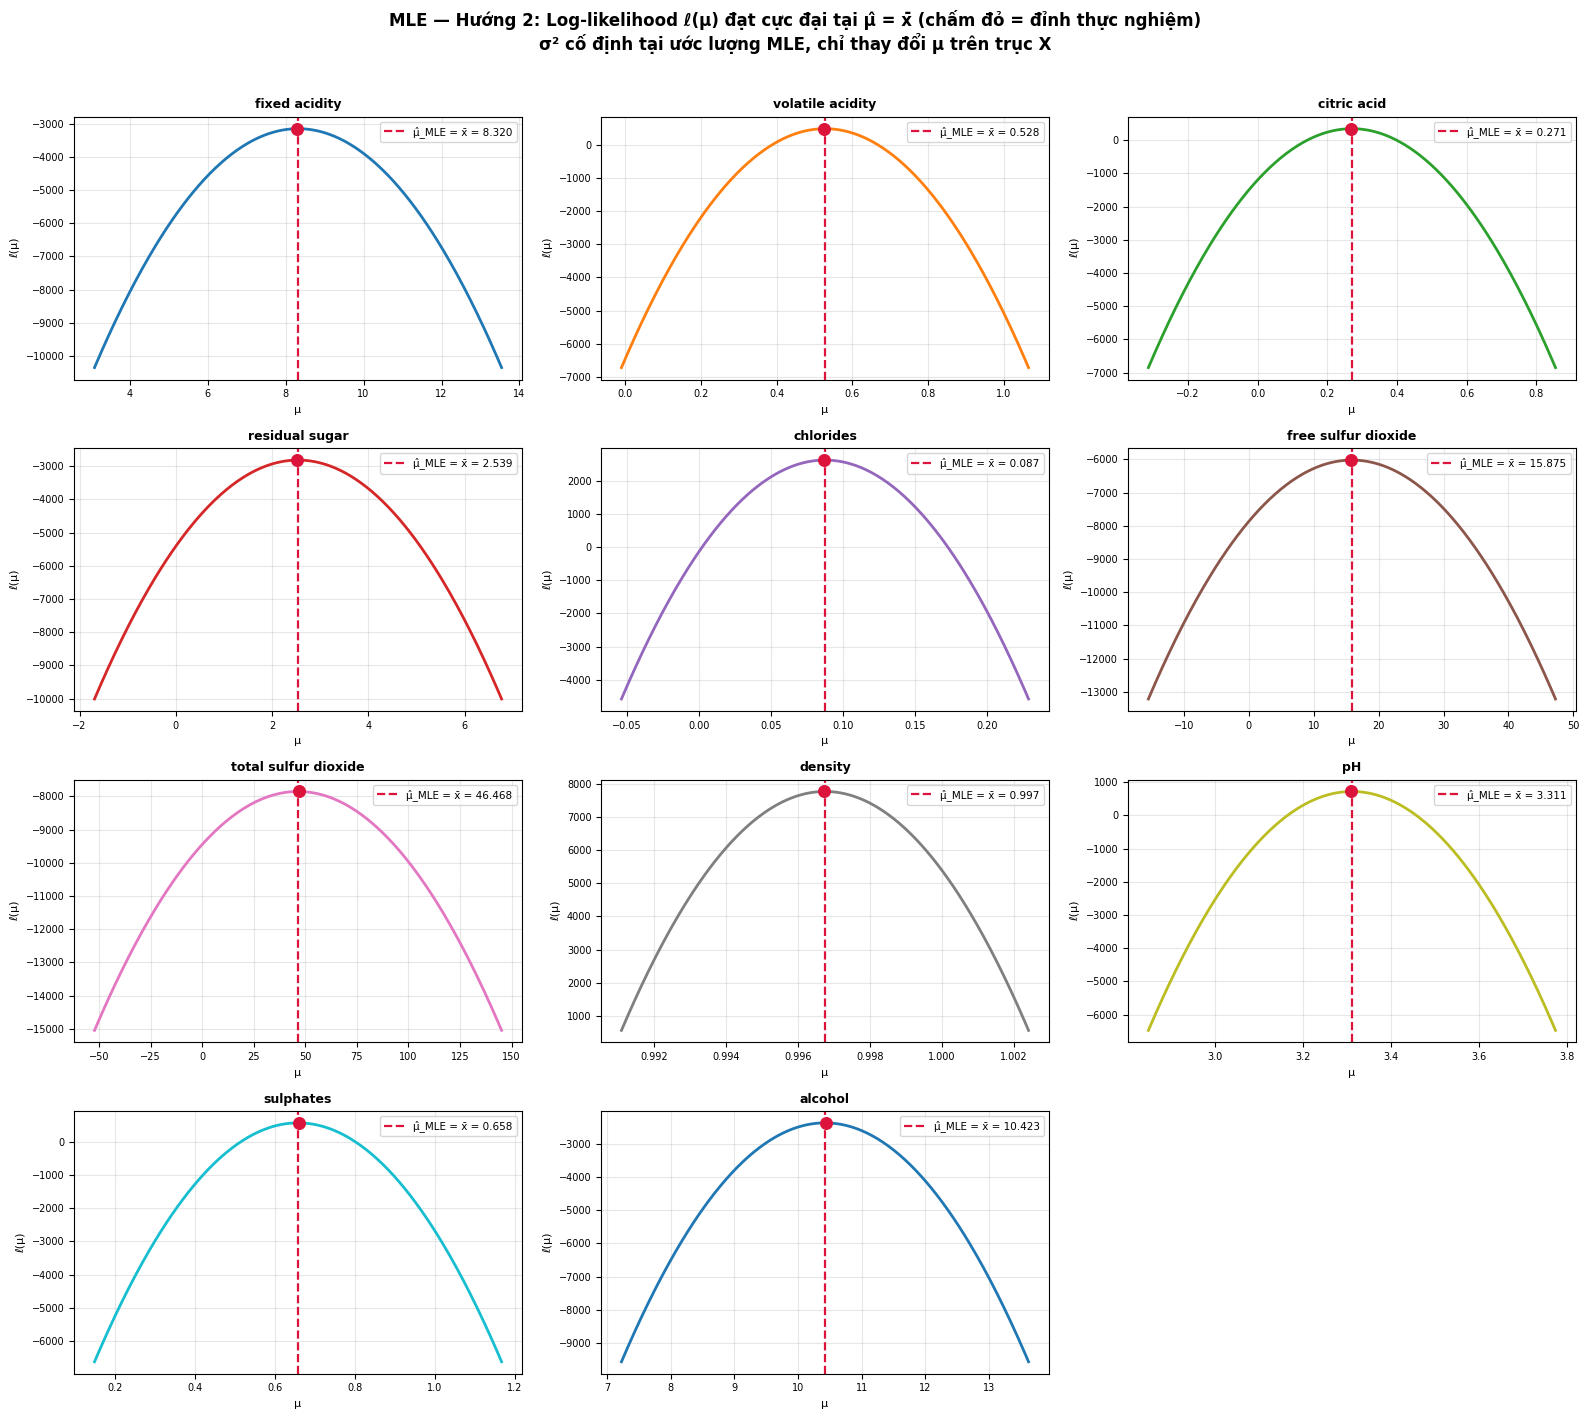

In [41]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()
colors_mle = sns.color_palette("tab10", len(var_list))

for i, (col, color) in enumerate(zip(var_list, colors_mle)):
    ax = axes[i]
    mu_true    = mle_results[col]['mu_hat']
    sigma2_hat = mle_results[col]['sigma2_hat']
    sigma_hat  = mle_results[col]['sigma_hat']
    data_col   = features[col].values

    mu_range = np.linspace(mu_true - 3 * sigma_hat, mu_true + 3 * sigma_hat, 300)
    log_liks = np.array([
        log_likelihood_univariate(data_col, m, sigma2_hat)
        for m in mu_range
    ])

    ax.plot(mu_range, log_liks, color=color, lw=2)
    peak_idx = np.argmax(log_liks)
    ax.scatter([mu_range[peak_idx]], [log_liks[peak_idx]],
               color='crimson', s=70, zorder=5)
    ax.axvline(mu_true, color='crimson', lw=1.6, ls='--',
               label=f'μ̂_MLE = x̄ = {mu_true:.3f}')
    ax.set_title(f'{col}', fontsize=9, fontweight='bold')
    ax.set_xlabel('μ', fontsize=8)
    ax.set_ylabel('ℓ(μ)', fontsize=8)
    ax.legend(fontsize=7.5)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=7)

for j in range(len(var_list), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'MLE — Hướng 2: Log-likelihood ℓ(μ) đạt cực đại tại μ̂ = x̄ (chấm đỏ = đỉnh thực nghiệm)\n'
    'σ² cố định tại ước lượng MLE, chỉ thay đổi μ trên trục X',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

### Nhận xét

Tất cả 11 biến đều thể hiện cùng một hành vi nhất quán:

- **Hình dạng lõm xuống** — đảm bảo tồn tại cực đại toàn cục duy nhất, không bị sa vào local maximum.
- **Đỉnh rơi chính xác tại $\bar{x}$** — xác nhận thực nghiệm lời giải giải tích μ̂_MLE = x̄.
- **Độ rộng của parabol phản ánh độ không chắc chắn của ước lượng**: parabol rộng → phương sai ước lượng μ lớn → cần thêm dữ liệu để thu hẹp.

**Quan sát đáng chú ý:**

| Biến | μ̂_MLE | Nhận xét về hình dạng ℓ(μ) |
|---|---:|---|
| density | 0.9967 | Parabol **cực kỳ hẹp** — ước lượng μ rất chính xác, phân tán thấp nhất trong 11 biến |
| total SO₂ | 46.468 | Parabol **rất rộng** — dao động lớn, ước lượng kém chắc chắn hơn |
| citric acid | 0.271 | Đỉnh gần 0 — nhiều mẫu có giá trị 0, phân phối không chuẩn → giả định N(μ,σ²) kém phù hợp nhất |
| fixed acidity | 8.320 | Cân xứng tốt — phân phối gần chuẩn, MLE hoạt động tốt nhất ở đây |

---

### 2.6 Kiểm chứng — Log-likelihood theo $\sigma^2$

Cố định $\mu = \bar{x}$, thay đổi $\sigma^2$. Đỉnh phải rơi đúng tại $\hat{\sigma}^2_{MLE}$ (đường đỏ, chia $n$), không phải tại $S^2$ (đường xanh, chia $n-1$).

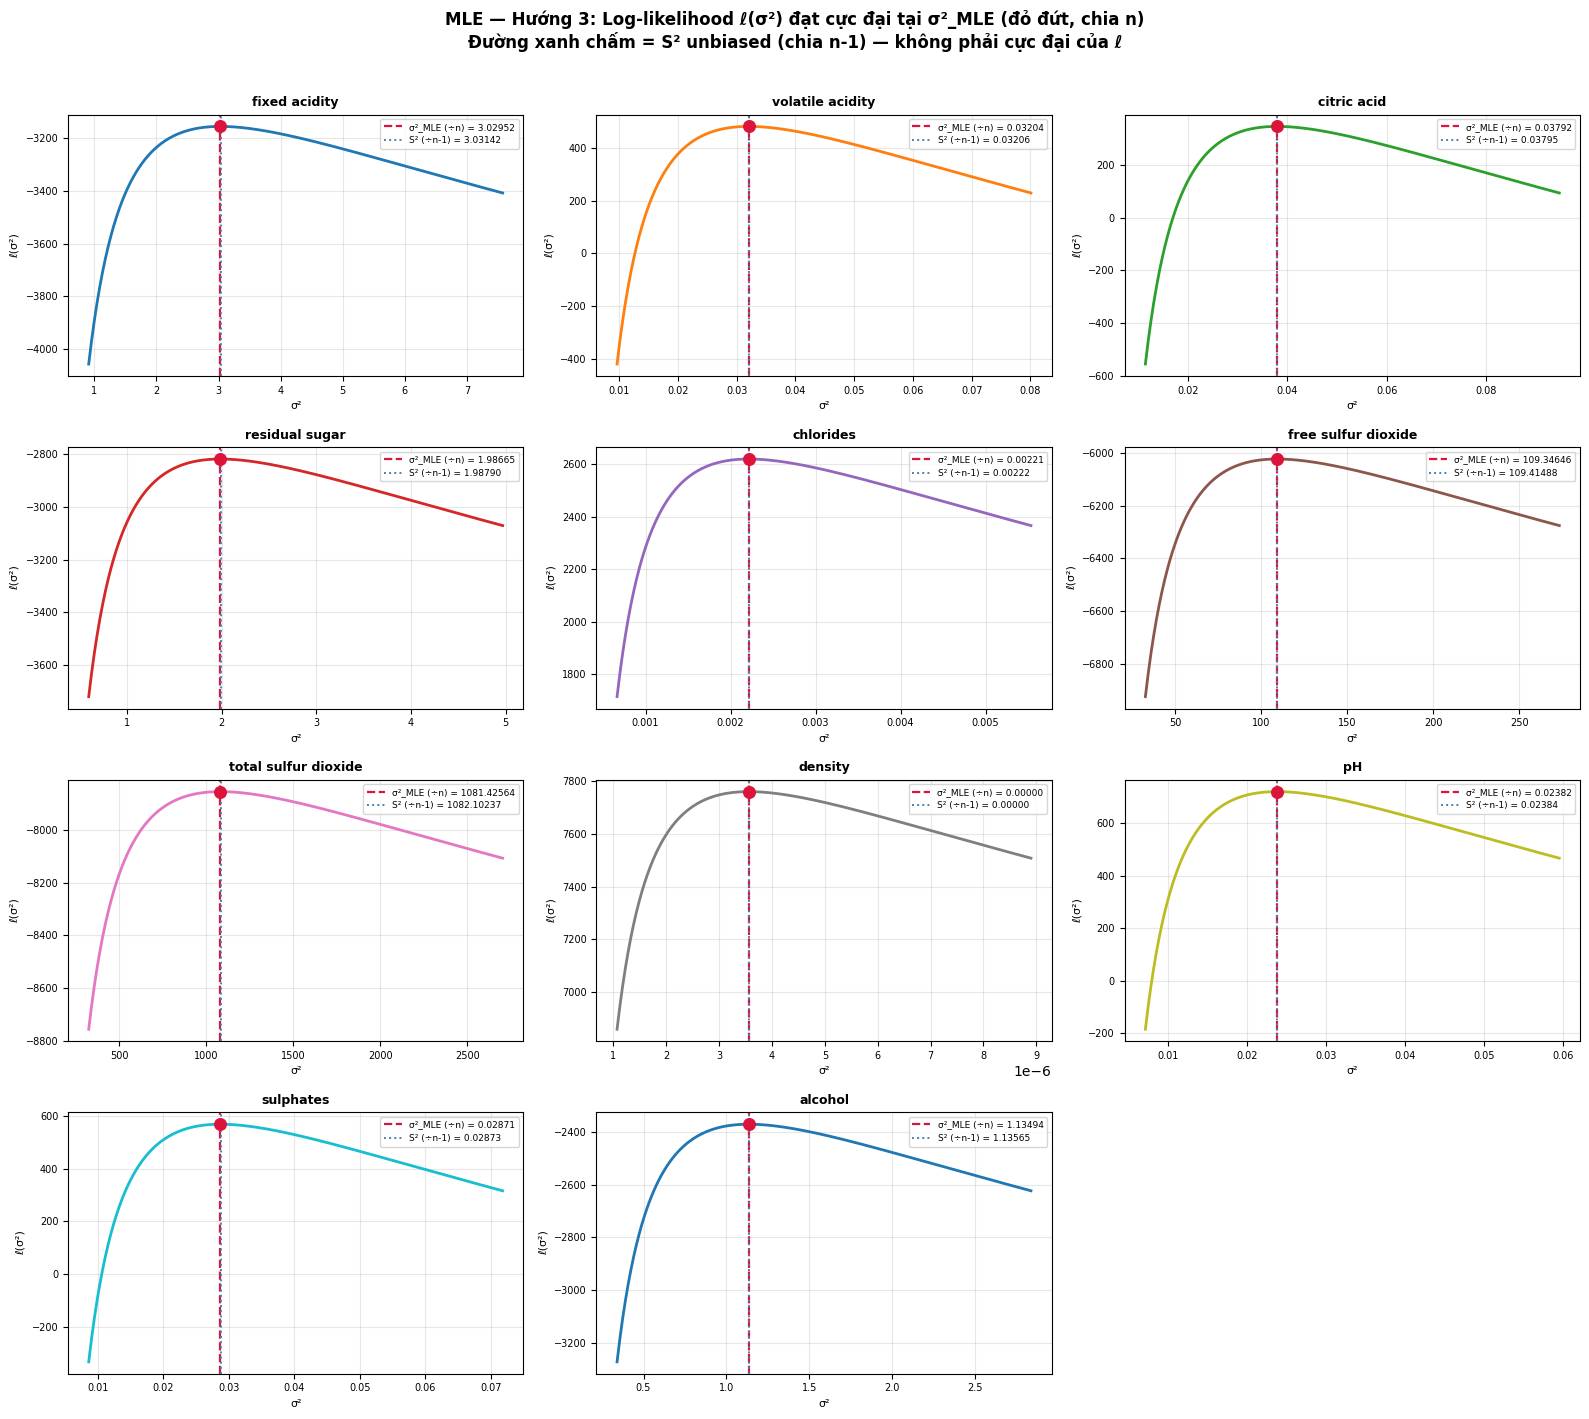

In [42]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(var_list, colors_mle)):
    ax = axes[i]
    mu_hat_col = mle_results[col]['mu_hat']
    sigma2_mle = mle_results[col]['sigma2_hat']   # chia n
    sigma2_unb = variance(features[col])           # chia n-1
    data_col   = features[col].values

    s2_range = np.linspace(0.3 * sigma2_mle, 2.5 * sigma2_mle, 300)
    log_liks = np.array([
        log_likelihood_univariate(data_col, mu_hat_col, s2)
        for s2 in s2_range
    ])

    ax.plot(s2_range, log_liks, color=color, lw=2)
    peak_idx = np.argmax(log_liks)
    ax.scatter([s2_range[peak_idx]], [log_liks[peak_idx]],
               color='crimson', s=70, zorder=5)
    ax.axvline(sigma2_mle, color='crimson',   lw=1.6, ls='--',
               label=f'σ²_MLE (÷n) = {sigma2_mle:.5f}')
    ax.axvline(sigma2_unb, color='steelblue', lw=1.4, ls=':',
               label=f'S² (÷n-1) = {sigma2_unb:.5f}')

    ax.set_title(f'{col}', fontsize=9, fontweight='bold')
    ax.set_xlabel('σ²', fontsize=8)
    ax.set_ylabel('ℓ(σ²)', fontsize=8)
    ax.legend(fontsize=6.5)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=7)

for j in range(len(var_list), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'MLE — Hướng 3: Log-likelihood ℓ(σ²) đạt cực đại tại σ²_MLE (đỏ đứt, chia n)\n'
    'Đường xanh chấm = S² unbiased (chia n-1) — không phải cực đại của ℓ',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

### Nhận xét

Với mọi biến, đường ℓ(σ²) đều:
- **Đạt cực đại (chấm đỏ) tại σ̂²_MLE (đường đỏ, chia n)** — xác nhận thực nghiệm lời giải giải tích.
- **Đường xanh chấm (S², chia n−1) nằm bên phải đỉnh một chút** — S² lớn hơn σ̂²_MLE một lượng n/(n−1), tức là nằm ở "sườn đi xuống" của hàm log-likelihood, không phải tại đỉnh.
- **Dạng hàm lệch phải** (asymmetric): ℓ(σ²) tăng nhanh khi σ² < σ̂²_MLE và giảm chậm khi σ² > σ̂²_MLE — ý nghĩa thực tiễn là **ước lượng thiếu phương sai nguy hiểm hơn ước lượng thừa phương sai**.

### 2.7 Nhận xét MLE

Chỉ số đánh giá: **Hệ số biến thiên** CV = σ̂ / μ̂ (phần trăm dao động so với trung bình).

| Biến | μ̂ | σ̂ | CV (%) | 
|---|---:|---:|---:|
| density | 0.9967 | 0.0019 | **0.19%** | 
| pH | 3.311 | 0.154 | **4.7%** | 
| chlorides | 0.0875 | 0.047 | **53.8%** | 
| volatile acidity | 0.5278 | 0.179 | **33.9%** | 
| fixed acidity | 8.320 | 1.741 | **20.9%** | 
| residual sugar | 2.539 | 1.410 | **55.5%** | 
| sulphates | 0.658 | 0.170 | **25.8%** | 
| citric acid | 0.271 | 0.195 | **71.9%** | 
| alcohol | 10.423 | 1.065 | **10.2%** | 
| free SO₂ | 15.875 | 10.457 | **65.9%** | 
| total SO₂ | 46.468 | 32.885 | **70.8%** | 

---

**Giới hạn của mô hình MLE chuẩn N(μ,Σ)**

MLE trên giả định phân phối chuẩn hoạt động tốt khi dữ liệu thực sự chuẩn. Tuy nhiên, từ kết quả trên, một số biến **vi phạm giả định này**:

- `total SO₂`, `free SO₂`, `residual sugar`: CV > 65% và phân phối lệch phải rõ rệt trong dữ liệu gốc → ℓ(μ) và ℓ(σ²) vẽ ra có vẻ concave nhưng mô hình chuẩn không nắm bắt được đuôi dài bên phải.
- `citric acid`: Nhiều mẫu có giá trị = 0 → phân phối hỗn hợp (zero-inflated), không phải chuẩn.
- `density`, `pH`: Rất gần chuẩn → MLE hoạt động chính xác nhất.

---

**Ý nghĩa thực tế**

#### Kiểm soát chất lượng

MLE cho ta **tiêu chuẩn kiểm tra nhanh** dựa trên khoảng tin cậy x̄ ± 2σ̂:

| Biến | Khoảng bình thường [x̄ − 2σ̂, x̄ + 2σ̂] | Nếu ngoài khoảng → quyết định |
|---|---|---|
| volatile acidity | [0.17, 0.89] g/dm³ | **Loại hoặc điều chỉnh ngay** — mùi giấm, ảnh hưởng thẳng đến điểm chất lượng |
| density | [0.993, 1.001] g/cm³ | Kiểm tra nồng độ cồn/đường, có thể pha loãng trái phép |
| pH | [3.00, 3.62] | Kiểm tra khả năng bảo quản và vi sinh |
| sulphates | [0.32, 1.00] g/dm³ | Điều chỉnh lượng chất bảo quản |
| alcohol | [8.29, 12.55] % | Kiểm tra quá trình lên men |

#### Công thức rượu

Ước lượng MLE cho ta biết **mặt bằng của thị trường** — trung bình của 1 599 chai rượu Vinho Verde đang thương mại. Nếu mục tiêu là:

**Tạo rượu trên mức trung bình:**
- Giảm `volatile acidity` xuống dưới 0.45 g/dm³ (thay vì 0.53) → giảm mùi giấm, tăng điểm cảm quan.
- Tăng `alcohol` lên 11–12.5% (thay vì 10.4) → tương quan dương với quality trong dữ liệu.
- Kiểm soát `sulphates` ở 0.65–0.80 g/dm³ → vừa đủ chất bảo quản mà không gây vị đắng.

**→ Tối ưu chi phí sản xuất:**
- `total SO₂` và `free SO₂` có CV > 65% → đây là hai biến kiểm soát **kém nhất** trên toàn ngành. Nhà máy nào kiểm soát được hai biến này chặt hơn đối thủ thì có lợi thế chi phí (tránh lãng phí chất bảo quản) và chất lượng đồng đều hơn.

#### Phát hiện sản phẩm lỗi 

Khoảng cách Mahalanobis dùng Σ̂_MLE:

$$d^2_j = (x_j - \hat{\mu})^\top \hat{\Sigma}^{-1}_{MLE} (x_j - \hat{\mu}) \sim \chi^2_{11}$$

Mẫu nào có $d_j^2$ > 24.7 (ngưỡng χ²₁₁ ở p=0.01) nên được kiểm tra thủ công. Đây là cách phát hiện lỗi **đa chiều** — một mẫu có thể hoàn toàn bình thường ở từng biến riêng lẻ nhưng bất thường khi xét tổng hợp cả 11 biến.

## 3. Law of Large Numbers - LLN

### 3.1 Tóm tắt lý thuyết
- **Phát biểu:** Cho dãy các biến ngẫu nhiên độc lập cùng phân phối (i.i.d) $X_1, X_2, ..., X_n$ có trung bình hữu hạn $E[X_i] = \mu$. Khi đó, trung bình mẫu $\bar{x}_n$ sẽ hội tụ theo xác suất về trung bình quần thể $\mu$:
  $$\bar{x}_n = \frac{1}{n} \sum_{i=1}^n X_i \rightarrow \mu \text{ khi } n \to \infty$$
- **Công thức sai số tương đối:** $\text{Error} = \frac{|\bar{x} - \mu|}{\mu}$

### 3.2 Ý tưởng mô phỏng

LLN phát biểu rằng $\bar{x}_n \rightarrow \mu$ khi $n \rightarrow \infty$. Để minh họa điều này, ta cần cho thấy **sai số giữa $\bar{x}_n$ và $\mu$ giảm dần khi $n$ tăng lên**.

Cụ thể, với mỗi giá trị $n$, ta tính $\bar{x}_n$ rồi đo sai số tương đối so với $\mu$ thật:

$$\text{Error}(n) = \frac{|\bar{x}_n - \mu|}{\mu}$$

Nếu LLN đúng, đường $\text{Error}(n)$ phải giảm dần về $0$ khi $n$ tăng.

---

**Tại sao phải shuffle trước khi tính?**

Dataset gốc không ngẫu nhiên — các mẫu có thể được sắp xếp theo một thứ tự nhất định. Nếu tính trực tiếp trên thứ tự gốc, $\bar{x}_n$ ở các $n$ nhỏ sẽ bị lệch do chỉ đại diện cho một nhóm mẫu có tính chất tương đồng, không phản ánh đúng quần thể. Shuffle ngẫu nhiên trước khi tính đảm bảo mỗi bước $n$ đều lấy mẫu đại diện.

Sau khi shuffle, ta tính **trung bình tích lũy**: tại mỗi bước $n$, lấy trung bình của $n$ phần tử đầu tiên trong dãy đã shuffle.

$$n = 1 \rightarrow \bar{x}_1 = x_{52}$$

$$n = 2 \rightarrow \bar{x}_2 = \frac{x_{52} + x_{3}}{2}$$

$$n = 3 \rightarrow \bar{x}_3 = \frac{x_{52} + x_{3} + x_{810}}{3}$$

$$\vdots$$

$$n = N \rightarrow \bar{x}_N \approx \mu$$

---

**Tại sao cần lặp 100 lần?**

Mỗi lần shuffle cho ra một thứ tự ngẫu nhiên khác nhau, dẫn đến một tập hợp các sai số khác nhau. Nếu chỉ chạy một lần, kết quả phụ thuộc vào may rủi của lần shuffle đó và không đại diện cho hành vi chung của LLN.

Lặp lại toàn bộ quá trình $100$ lần — mỗi lần shuffle khác nhau, mỗi lần cho ra một tập hợp các sai số — rồi tổng hợp lại. Kết quả thu được là **trung bình của $100$ tập hợp các sai số** cùng với **$95\%$ confidence band**, phản ánh hành vi thực sự của LLN thay vì một kịch bản ngẫu nhiên đơn lẻ.

---

#### Các bước thực hiện

**Bước 1 — Xác định các giá trị $n$ cần tính**

Thay vì tính tại mọi $n$ từ $1$ đến $1599$ (tốn thời gian), ta chọn các mốc cách đều với bước nhảy $20$:

$$n \in \{20, 40, 60, \ldots, 1599\}$$

**Bước 2 — Lặp 100 lần, mỗi lần shuffle toàn bộ dataset**

Dùng `np.random.permutation` để sinh ra một thứ tự chỉ số ngẫu nhiên mới rồi áp dụng lên dataset. Mỗi trial cho ra một dãy dữ liệu được xáo trộn độc lập.

**Bước 3 — Tính trung bình tích lũy bằng cumulative sum**

Thay vì tính `mean(data[:10])`, `mean(data[:30])`,... từng cái một trong một vòng lặp, ta dùng `np.cumsum` để tính tổng tích lũy toàn bộ dãy **một lần duy nhất**, sau đó lấy đúng các vị trí $n$ cần thiết rồi chia cho $n$:

$$\bar{x}_n = \frac{\text{cumsum}[n-1]}{n}$$

Cách này tránh được vòng lặp lồng nhau, nhanh hơn đáng kể.

**Bước 4 — Tính sai số tương đối tại mỗi $n$**

$$\text{Error}(n) = \frac{|\bar{x}_n - \mu|}{\mu}$$

Mỗi trial cho ra một mảng sai số có độ dài bằng số mốc $n$ đã chọn ở Bước 1.

**Bước 5 — Tổng hợp kết quả của 100 trial**

Xếp $100$ mảng sai số thành ma trận shape $(100, \, \text{len(sizes)})$, sau đó tính mean và std theo chiều trial:

$$\text{mean\_error}(n) = \frac{1}{100} \sum_{t=1}^{100} \text{Error}_t(n)$$

$$\text{band}(n) = \text{mean\_error}(n) \pm 1.96 \cdot \text{std\_error}(n)$$

In [43]:
np.random.seed(42)
# Thực hiện mô phỏng LLN qua 100 lần chạy
all_trials_errors, sizes = simulate_lln(features, pop_means, n_trials=100, step=20)

display(Markdown(f"#### **Đã thực hiện 100 lần mô phỏng LLN.**"))

all_trials_errors_df = pd.DataFrame({
    col: np.mean(all_trials_errors[col], axis=0) for col in features.columns
}, index=sizes)
display(Markdown("#### Sai số trung bình sau 100 lần lặp của các biến theo mỗi kích thước mẫu:"))
display(all_trials_errors_df.round(6))

#### **Đã thực hiện 100 lần mô phỏng LLN.**

#### Sai số trung bình sau 100 lần lặp của các biến theo mỗi kích thước mẫu:

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
20,0.034164,0.064910,0.131471,0.098956,0.085690,0.121118,0.122455,0.000348,0.007937,0.045160,0.019248
40,0.024583,0.045347,0.095534,0.067820,0.061668,0.077260,0.071375,0.000248,0.006195,0.033290,0.013669
60,0.019240,0.035737,0.075261,0.055806,0.051864,0.065644,0.064535,0.000175,0.004503,0.028932,0.010035
80,0.016410,0.031010,0.060765,0.050141,0.053256,0.055568,0.054405,0.000158,0.003937,0.024953,0.009249
100,0.014904,0.026873,0.051820,0.045377,0.049939,0.052680,0.047324,0.000138,0.003602,0.020940,0.007858
...,...,...,...,...,...,...,...,...,...,...,...
1520,0.000899,0.001485,0.003521,0.002565,0.002264,0.002526,0.002676,0.000009,0.000233,0.001173,0.000426
1540,0.000775,0.001391,0.003038,0.002276,0.002057,0.002260,0.002196,0.000007,0.000197,0.000987,0.000375
1560,0.000629,0.001125,0.002482,0.001671,0.001850,0.001832,0.001953,0.000006,0.000166,0.000792,0.000310
1580,0.000401,0.000694,0.001531,0.001099,0.001286,0.001377,0.001363,0.000004,0.000106,0.000569,0.000199


### 3.4 Trực quan hóa hội tụ LLN

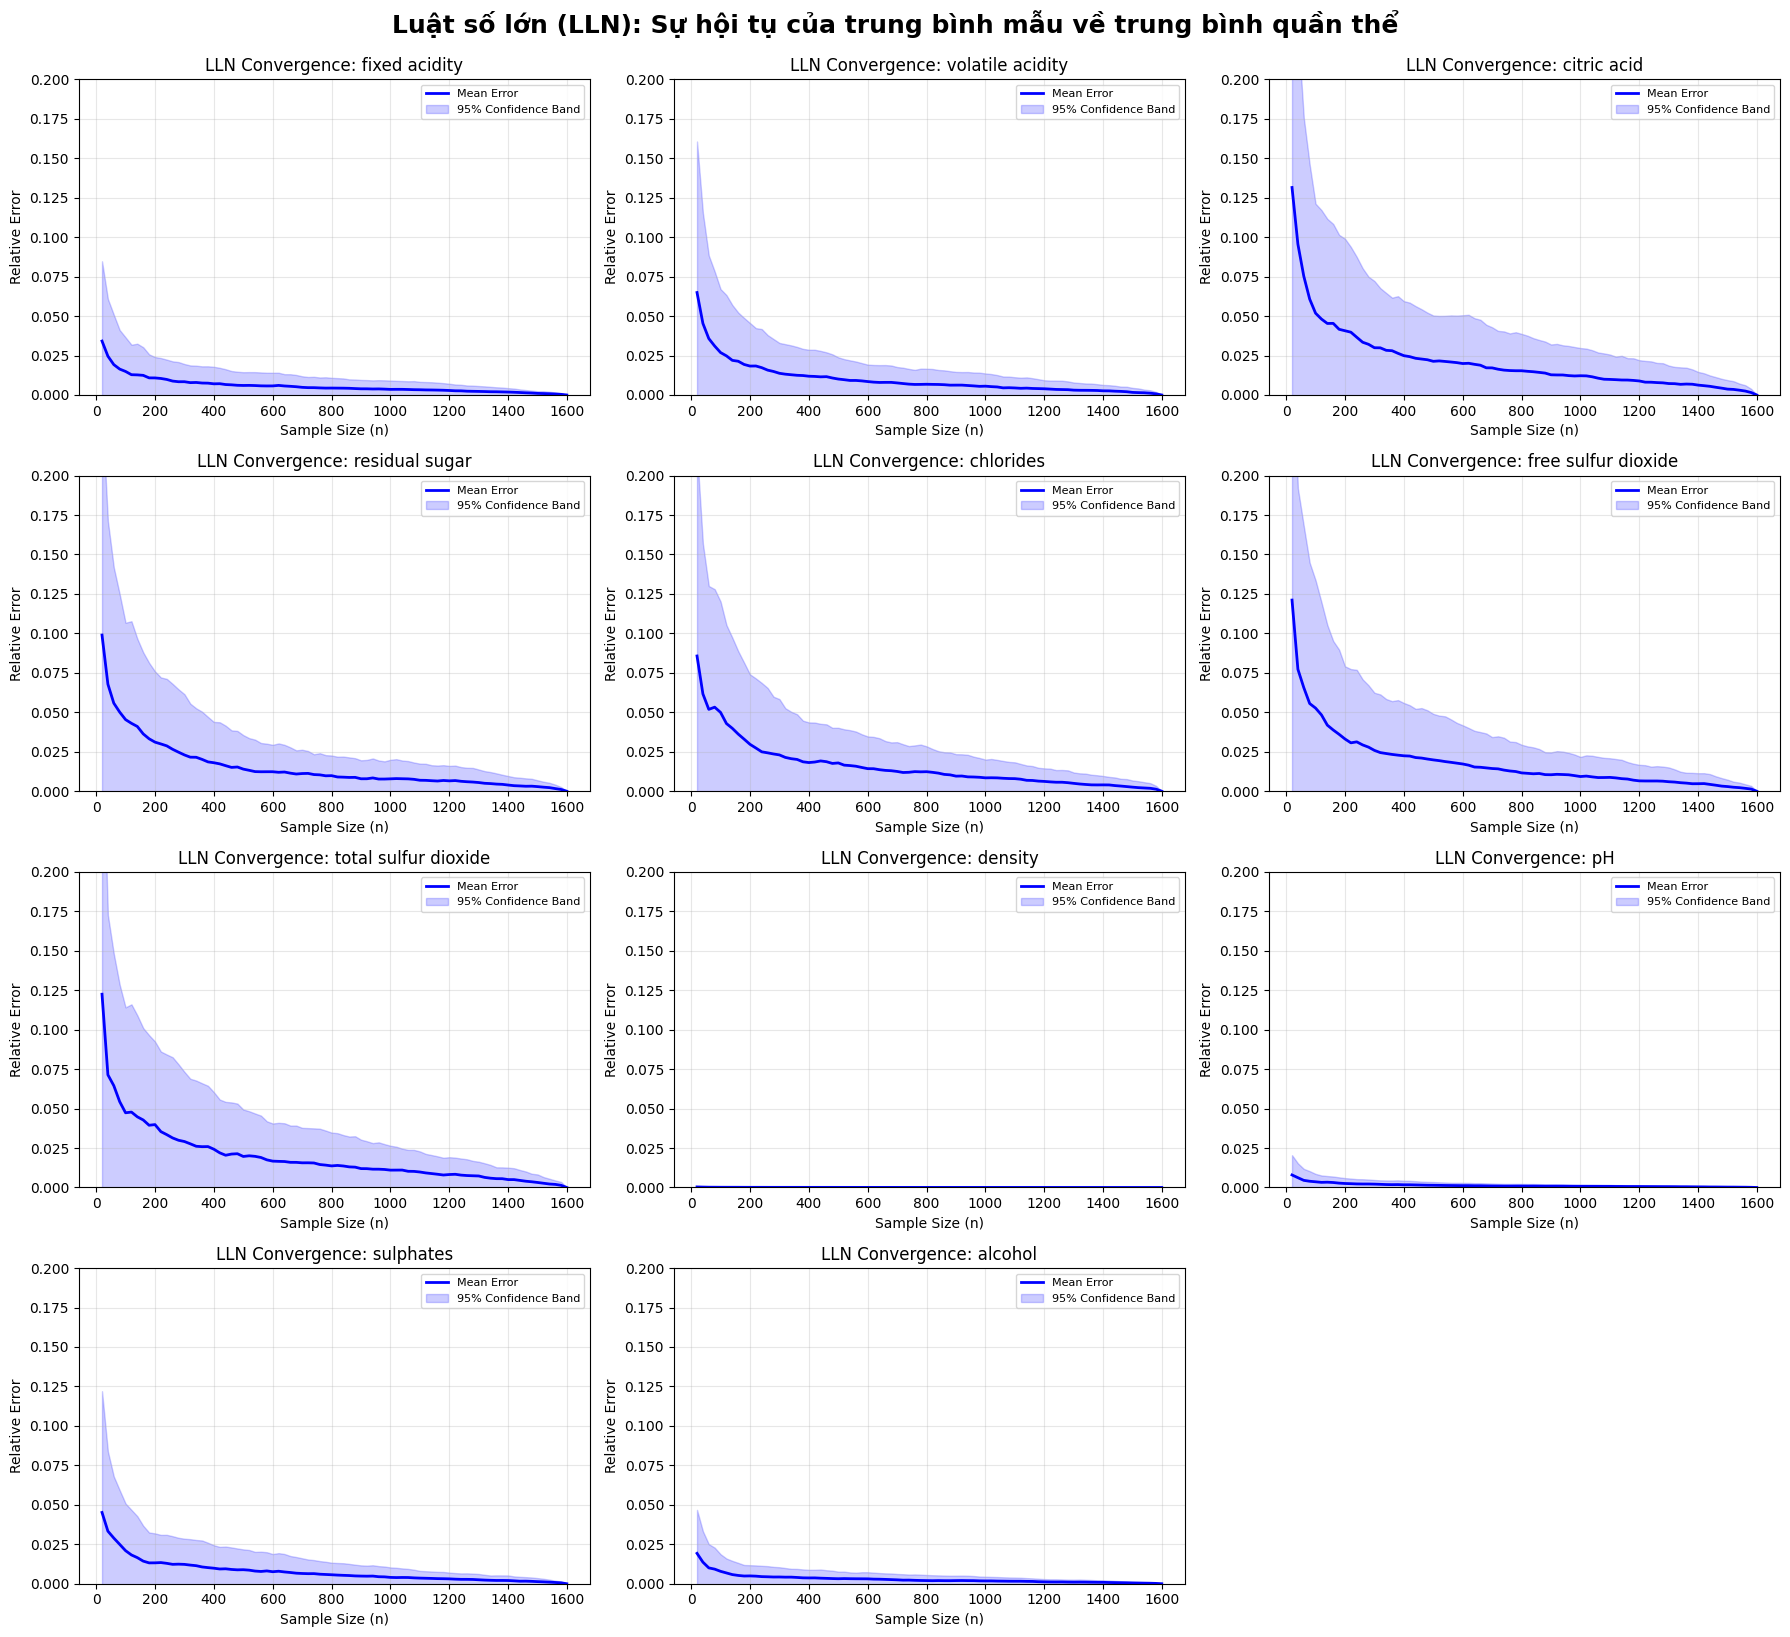

In [44]:
# Vẽ lưới biểu đồ cho tất cả 11 biến
plot_lln_convergence_grid(all_trials_errors, sizes)

**LLN hoạt động đúng với tất cả 11 biến.** Đường Mean Error của mọi biến đều giảm đơn điệu về $0$ khi $n$ tăng — đúng với phát biểu $\bar{x}_n \xrightarrow{P} \mu$ khi $n \rightarrow \infty$.

**Tốc độ hội tụ khác nhau giữa các biến**, và sự khác biệt này liên quan trực tiếp đến độ lệch chuẩn $\sigma$ của từng biến. Biến có $\sigma$ lớn so với $\mu$ (hệ số biến thiên $\sigma/\mu$ cao) có trung bình mẫu dao động nhiều hơn, dẫn đến hội tụ chậm hơn. Cụ thể:

- `total sulfur dioxide`, `free sulfur dioxide`, `residual sugar`, `citric acid` có đường sai số bắt đầu cao (trên $0.10$–$0.15$) và cần $n$ lớn hơn để giảm xuống gần $0$ — phản ánh $\sigma/\mu$ lớn của các biến này.
- `density`, `pH` hội tụ rất nhanh ngay từ $n$ nhỏ, đường sai số gần như phẳng sau $n \approx 100$ — do $\sigma/\mu$ của hai biến này rất nhỏ, trung bình mẫu ít biến động.

**Confidence band hẹp dần khi $n$ tăng** ở tất cả các biến, phản ánh $\text{Var}(\bar{x}_n) = \sigma^2/n$ giảm theo $n$. Band rộng ở vùng $n$ nhỏ cho thấy kết quả không ổn định và phụ thuộc nhiều vào thứ tự lấy mẫu — đây là lý do cần lặp 100 lần thay vì chỉ chạy một lần duy nhất.

## 4. Central Limit Theorem - CLT

### 4.1 Tóm tắt lý thuyết
- **Phát biểu:** Cho dãy các biến ngẫu nhiên độc lập cùng phân phối có trung bình $\mu$ và phương sai $\sigma^2$ hữu hạn. Khi $n$ đủ lớn ($n \to \infty$), phân phối của trung bình mẫu $\bar{x}_n$ sẽ xấp xỉ phân phối chuẩn:
  $$\bar{x}_n \xrightarrow{d} \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right)$$
  Hay dạng chuẩn hóa (Z-score):
  $$Z = \frac{\bar{x}_n - \mu}{\sigma/\sqrt{n}} \xrightarrow{d} \mathcal{N}(0, 1)$$
- **Điều kiện:** Thông thường $n \geq 30$ được coi là đủ lớn để xấp xỉ chuẩn tốt cho hầu hết các phân phối. Với các phân phối lệch nhiều, $n$ cần lớn hơn.

### 4.2 Ảnh hưởng của $n$ — So sánh quá trình hội tụ
Chúng ta sẽ lấy mẫu với các kích thước $n \in \{5, 10, 30, 50, 100\}$. Với mỗi $n$, thực hiện 1000 lần lấy mẫu để vẽ phân phối của $\bar{x}$.

In [45]:
np.random.seed(42)
sample_sizes = [5, 10, 30, 50, 100]
n_trials = 1000

# Thực hiện mô phỏng CLT
clt_results = simulate_clt(features, sample_sizes=sample_sizes, n_trials=n_trials)

display(Markdown(f"#### **Mô phỏng CLT hoàn tất với {n_trials} trials cho mỗi kích thước mẫu $n$.**"))

#### **Mô phỏng CLT hoàn tất với 1000 trials cho mỗi kích thước mẫu $n$.**

### 4.3 Trực quan hóa CLT hội tụ

In [46]:
# Vẽ lưới biểu đồ hội tụ chuẩn cho tất cả các biến
plot_clt_convergence_grid(clt_results, sample_sizes, pop_means, pop_stds)

AttributeError: 'NoneType' object has no attribute 'keys'

**CLT hoạt động đúng với tất cả 11 biến.** Khi $n$ tăng từ $5$ lên $100$, histogram của $\bar{x}$ ở mọi biến đều hội tụ dần về dạng chuẩn $\mathcal{N}(\mu, \sigma^2/n)$ — đúng với phát biểu của CLT, bất kể phân phối gốc của biến đó có hình dạng như thế nào.

**Tốc độ hội tụ phụ thuộc vào độ lệch của phân phối gốc.** Quan sát rõ nhất ở hai nhóm:

- `density`, `pH`, `fixed acidity`, `volatile acidity`: Histogram đã khá chuẩn ngay từ $n = 5$–$10$ vì phân phối gốc của các biến này tương đối đối xứng, ít lệch.
- `residual sugar`, `chlorides`: Phân phối gốc lệch phải rõ rệt, nên ở $n = 5$ histogram của $\bar{x}$ vẫn còn lệch và có đuôi phải dài. Phải đến $n = 30$–$50$ histogram mới bắt đầu khớp tốt với đường chuẩn lý thuyết.

**Đường chuẩn lý thuyết $\mathcal{N}(\mu, \sigma^2/n)$ khớp tốt with histogram thực nghiệm** ở hầu hết các biến khi $n \geq 30$, xác nhận rằng ngưỡng $n \geq 30$ thường được dùng trong thực tế là hợp lý — ngoại trừ các biến có độ lệch cao như `residual sugar` và `chlorides` cần $n$ lớn hơn để đạt xấp xỉ tốt.

#### ***Chuẩn hóa về Z-score***
Ngoài ra ta có thể chuyển đổi trung bình mẫu $\bar{x}$ về $Z = \frac{\bar{x} - \mu}{\sigma/\sqrt{n}}$ để đưa tất cả các biến về cùng một thang đo $\mathcal{N}(0, 1)$, sau đó chồng chúng lại để quan sát rõ hơn. Chúng ta sẽ quan sát tại $n=100$.

**Note:** Đây chỉ là một cách trực quan hóa thay thế — đưa tất cả biến về cùng thang đo để dễ so sánh, không bổ sung thêm bằng chứng mới so với phần trên.

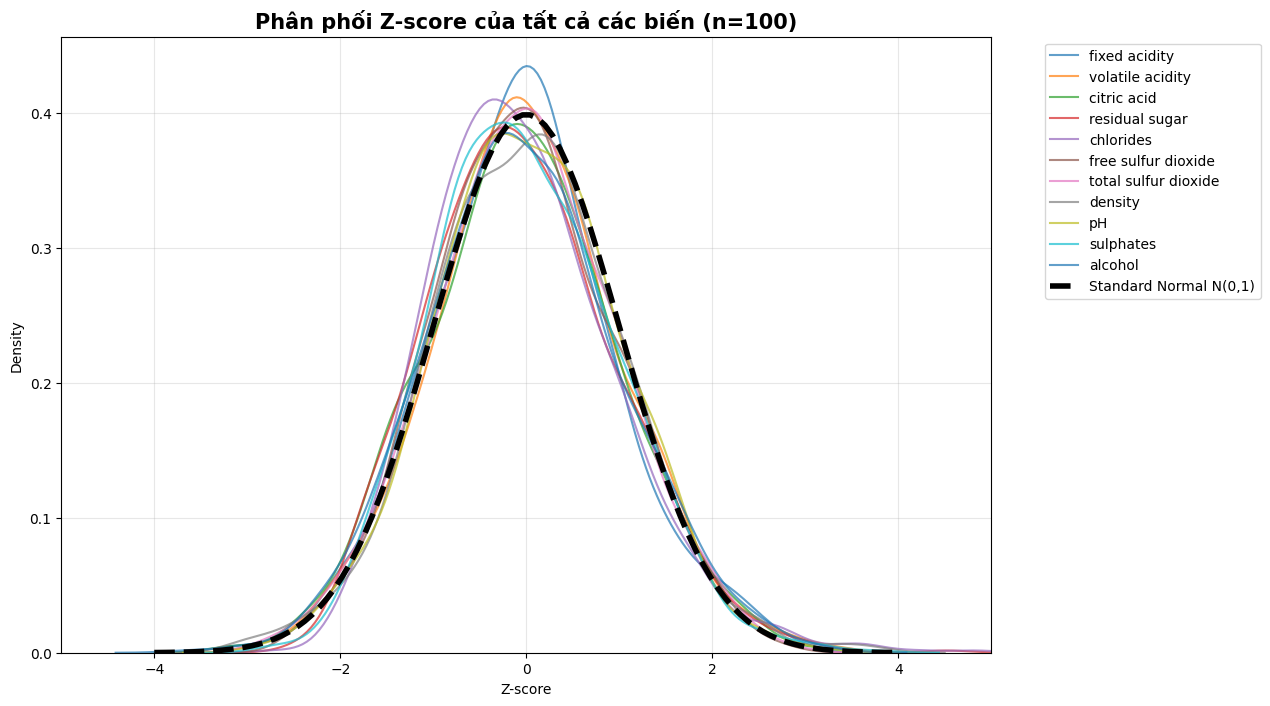

In [ ]:
n_fixed = 100
plt.figure(figsize=(12, 8))

for col in features.columns:
    means = np.array(clt_results[col][n_fixed])
    z_scores = (means - pop_means[col]) / (pop_stds[col] / np.sqrt(n_fixed))
    sns.kdeplot(z_scores, label=col, alpha=0.7)

x_norm = np.linspace(-4, 4, 100)
plt.plot(x_norm, stats.norm.pdf(x_norm, 0, 1), color='black', lw=4, ls='--', label='Standard Normal N(0,1)')

plt.title(f"Phân phối Z-score của tất cả các biến (n={n_fixed})", fontsize=15, fontweight='bold')
plt.xlabel("Z-score")
plt.ylabel("Density")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(-5, 5)
plt.show()

Tại $n = 100$, đường KDE của tất cả 11 biến đều **bám sát đường $\mathcal{N}(0,1)$** (đường đứt đen), xác nhận lại kết quả CLT trên toàn bộ dataset. Hai ngoại lệ nhỏ là `fixed acidity` có đỉnh cao hơn và `chlorides` có đỉnh hơi lệch sang trái một chút so với $\mathcal{N}(0,1)$. Còn lại bám khá sát.